# Trabalho Prático 02 - K-Means
**Base de dados:** Iris Dataset

## Etapa 1: Preparação e Limpeza dos Dados
Nesta primeira etapa, vamos preparar nossos dados para o algoritmo K-Means. Como se trata de um método de aprendizado não supervisionado, é fundamental removermos qualquer rótulo ou identificador prévio (como as colunas `Id` e `Species`) da entrada do modelo. As espécies reais serão guardadas apenas para análise posterior.

Além disso, aplicaremos a **Padronização (Z-Scoring)**. Esse processo centraliza cada variável em relação à média e a normaliza pelo desvio padrão. Isso garante que atributos com escalas diferentes não afetem negativamente o cálculo das distâncias matemáticas que o K-Means utiliza para formar os agrupamentos.

In [26]:
# Importando as bibliotecas necessárias
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Carregando a base de dados
# Certifique-se de que o arquivo 'Iris.csv' está na mesma pasta do seu Jupyter Notebook
df = pd.read_csv("Iris.csv")

# 2. Separando os atributos numéricos (X) dos rótulos
# O K-Means usará apenas as medidas das pétalas e sépalas
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Guardamos os rótulos reais apenas para conferência futura
rotulos_reais = df['Species'] 

# 3. Aplicando a Padronização (Z-Scoring)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Visualizando o resultado da primeira flor antes e depois
print("Valores originais da 1ª flor:\n", X.iloc[0].values)
print("\nValores padronizados da 1ª flor:\n", X_padronizado[0])

Valores originais da 1ª flor:
 [5.1 3.5 1.4 0.2]

Valores padronizados da 1ª flor:
 [-0.90068117  1.03205722 -1.3412724  -1.31297673]


## Etapa 2: Escolhendo o valor de K (Método do Cotovelo)
O algoritmo K-Means exige que o número de clusters ($K$) seja definido antes da execução. Para não escolhermos esse número de forma arbitrária, utilizaremos o **Método do Cotovelo (Elbow Method)** e a métrica de **Inércia (WCSS - Within-Cluster Sum of Squares)**. 

A Inércia mede o quão compactos estão os grupos (quanto menor, mais próximos os pontos estão de seus respectivos centroides). Executaremos o K-Means para vários valores de $K$ (de 1 a 10) e plotaremos a Inércia. O ponto ideal é o "cotovelo" do gráfico, onde a queda na Inércia deixa de ser acentuada, indicando que adicionar mais clusters não traz um ganho significativo na compactação.

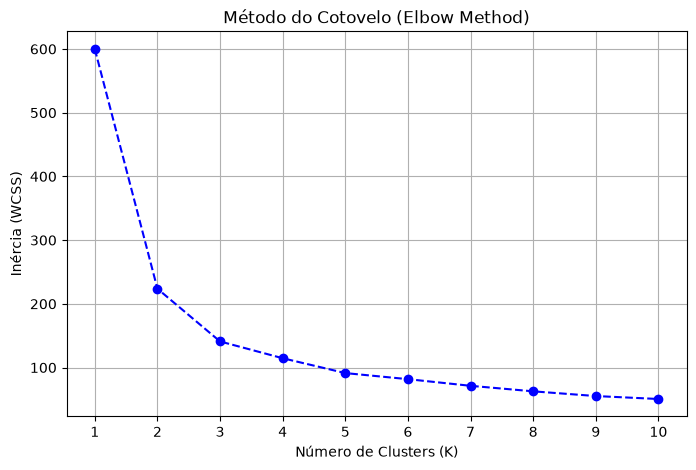

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Lista para guardar os valores de Inércia (WCSS)
wcss = []

# Testando valores de K de 1 a 10
valores_k = range(1, 11)

for k in valores_k:
    # random_state=42 garante que o resultado seja o mesmo toda vez que rodar
    # n_init=10 executa o algoritmo 10 vezes com centros iniciais diferentes e escolhe o melhor
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_padronizado)
    
    # kmeans.inertia_ retorna o valor do WCSS para aquele K
    wcss.append(kmeans.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(valores_k, wcss, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

## Etapa 3: Agrupamento Final e Avaliação (Silhouette Score)
Com base na análise do Método do Cotovelo e no nosso conhecimento prévio da base de dados, definimos o número de clusters como $K=3$. 

Agora, vamos treinar o modelo definitivo do K-Means com esse valor. Para avaliar a qualidade da separação dos grupos formada pelo algoritmo, utilizaremos o **Silhouette Score**. Essa métrica nos diz o quão similar um ponto de dados é em relação ao seu próprio cluster em comparação com outros clusters. Valores mais altos (próximos a 1) indicam agrupamentos bem separados e consistentes.

In [28]:
from sklearn.metrics import silhouette_score

# 1. Configurando e treinando o K-Means final com K=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
grupos_previstos = kmeans_final.fit_predict(X_padronizado)

# 2. Calculando o Silhouette Score
sil_score = silhouette_score(X_padronizado, grupos_previstos)

print(f"Silhouette Score para K=3: {sil_score:.4f}")

# 3. Adicionando os grupos previstos ao DataFrame original para análise
df_resultados = df.copy()
df_resultados['Grupo_KMeans'] = grupos_previstos

# Mostrando as primeiras linhas com o resultado
df_resultados.head()

Silhouette Score para K=3: 0.4590


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Grupo_KMeans
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


## Etapa 4: Visualização dos Agrupamentos com PCA
O conjunto de dados Iris possui 4 variáveis contínuas (4 dimensões). Para visualizarmos os clusters de forma bidimensional (2D), precisamos reduzir a dimensionalidade dos dados. 

Atendendo aos requisitos do trabalho, utilizaremos o **PCA (Análise de Componentes Principais)**. O PCA transforma as 4 variáveis originais em 2 novas variáveis (Componentes Principais) que retêm a maior parte da variação (informação) dos dados originais. Com isso, podemos criar um gráfico de dispersão (scatter plot) mostrando a separação dos grupos e onde os centroides finais se posicionaram.

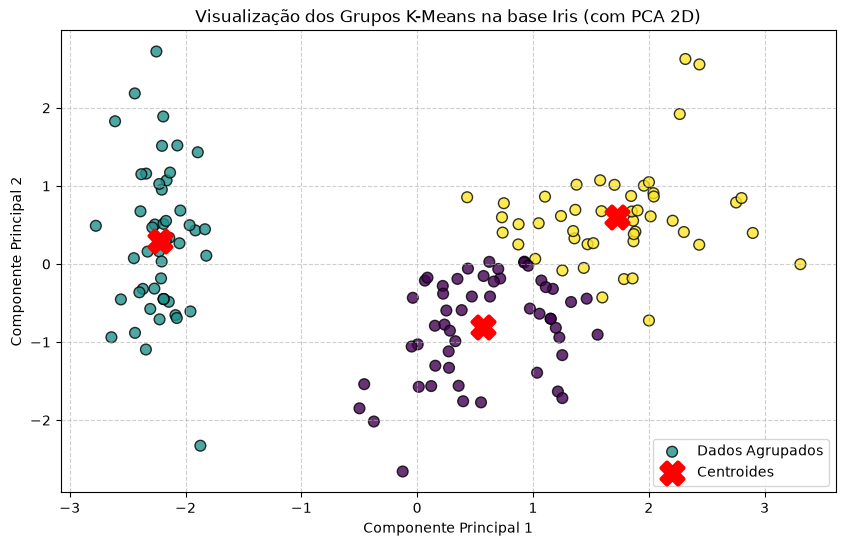

In [29]:
from sklearn.decomposition import PCA

# 1. Aplicando o PCA para reduzir de 4 para 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_padronizado)

# 2. Transformando também a posição dos centroides para o formato 2D
centroides_pca = pca.transform(kmeans_final.cluster_centers_)

# 3. Criando o gráfico de dispersão (Scatter Plot)
plt.figure(figsize=(10, 6))

# Plotando os pontos de dados coloridos pelos grupos previstos pelo K-Means
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=grupos_previstos, cmap='viridis', 
                      edgecolors='k', s=60, alpha=0.8, label='Dados Agrupados')

# Plotando os centroides com um marcador 'X' vermelho grande
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', 
            s=250, label='Centroides', linewidths=3)

# Configurações de layout do gráfico
plt.title('Visualização dos Grupos K-Means na base Iris (com PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()